In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import the dataset into Python
df = pd.read_csv('titanic.csv')

# Display Dataset dimensions
print("Dataset Dimensions:", df.shape)

# Display Column names
print("\nColumn Names:", df.columns.tolist())

# Display First five observations
print("\nFirst Five Observations:")
display(df.head())

# Display Data types
print("\nData Types:")
print(df.dtypes)

Dataset Dimensions: (891, 12)

Column Names: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

First Five Observations:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Data Types:
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [2]:
# Detect missing values
print("Missing values before cleaning:")
print(df.isnull().sum())

# Detect duplicated observations
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicated observations: {duplicates}")

# Handle missing values appropriately
# 1. Age: Fill missing values with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Embarked: Fill missing values with the mode (most common port)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Cabin: Drop the column entirely due to too many missing values
df = df.drop(columns=['Cabin'])

# Remove duplicates if any exist
if duplicates > 0:
    df = df.drop_duplicates()
    print("\nDuplicates removed.")

# Verify cleaning
print("\nMissing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Number of duplicated observations: 0

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


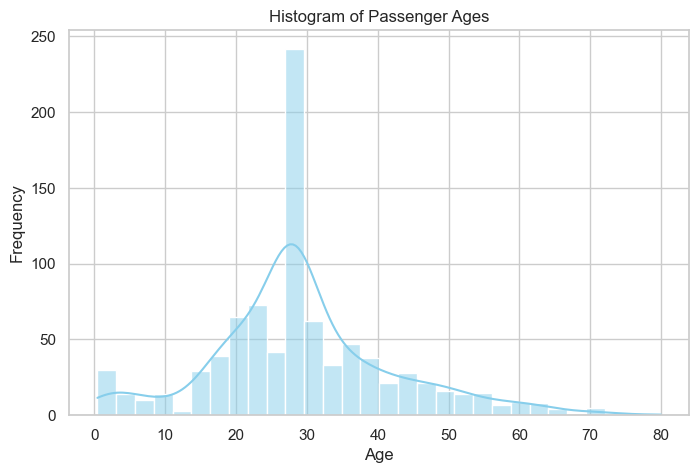

C:\Users\Ramadan\AppData\Local\Temp\ipykernel_3508\1292315729.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Pclass', palette='Set2')


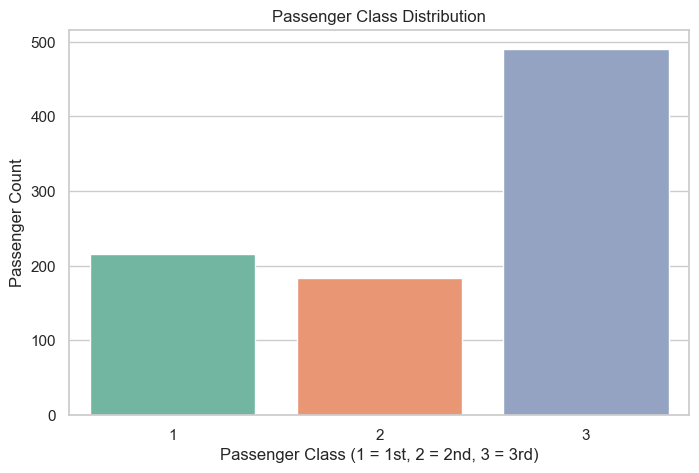

C:\Users\Ramadan\AppData\Local\Temp\ipykernel_3508\1292315729.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Pclass', y='Age', palette='Set3')


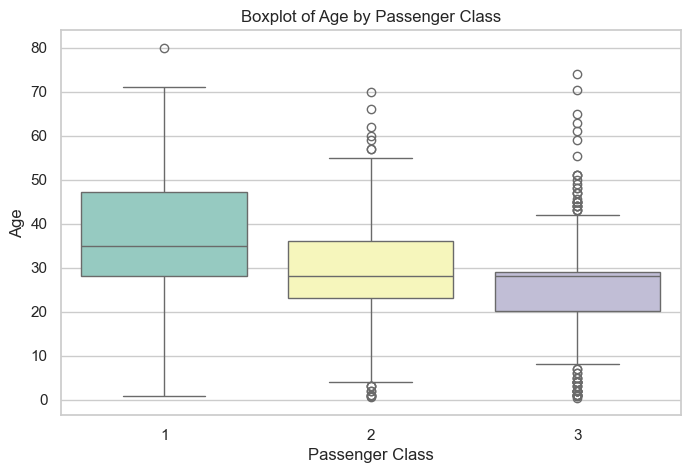

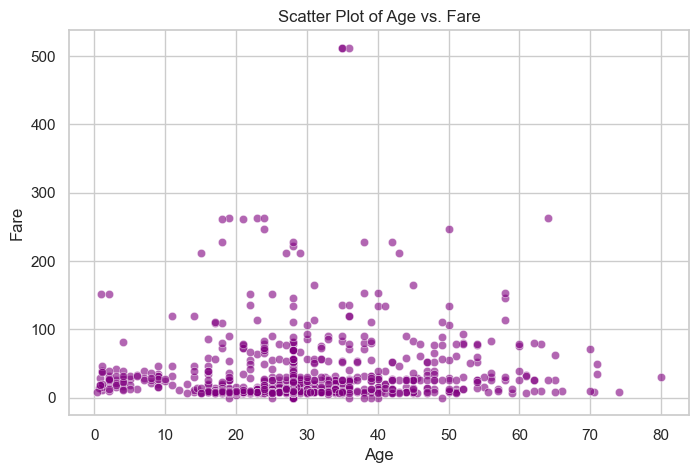

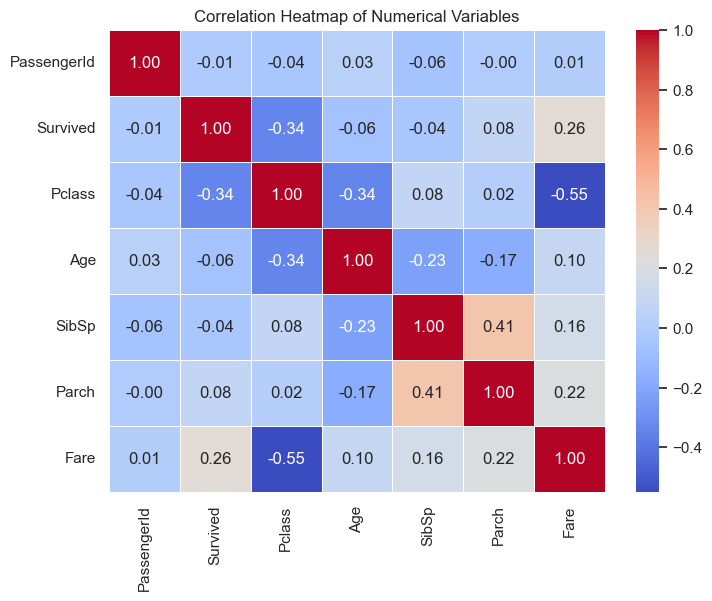

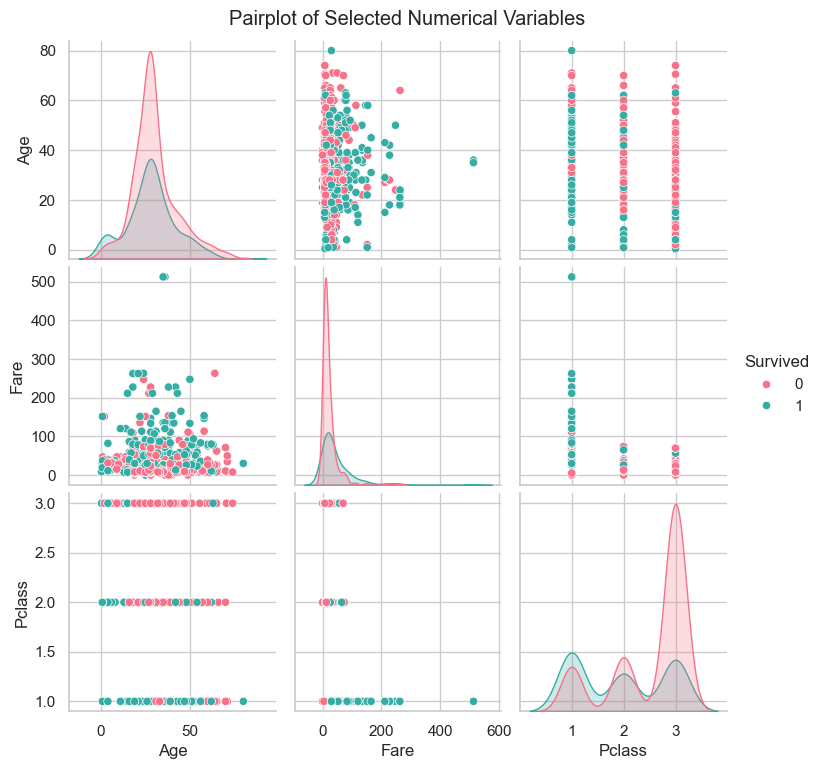

'\nMARKDOWN INTERPRETATION 6:\nThe pairplot visualizes the distributions and pairwise relationships. Looking at the survival hues, it highlights that passengers who paid higher fares or were in 1st class had noticeably higher survival rates.\n'

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all plots
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Histogram of passenger ages
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title('Histogram of Passenger Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

"""
MARKDOWN INTERPRETATION 1:
The age distribution is roughly normal but slightly right-skewed, with the majority of passengers aged between 20 and 30. There is also a notable peak in the distribution for toddlers and young children.
"""

# ---------------------------------------------------------
# 2. Bar chart showing passenger class distribution
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Pclass', palette='Set2')
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class (1 = 1st, 2 = 2nd, 3 = 3rd)')
plt.ylabel('Passenger Count')
plt.show()

"""
MARKDOWN INTERPRETATION 2:
Third-class (Pclass 3) had the highest number of passengers, significantly outnumbering first and second-class passengers combined.
"""

# ---------------------------------------------------------
# 3. Boxplot of age by passenger class
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Pclass', y='Age', palette='Set3')
plt.title('Boxplot of Age by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age')
plt.show()

"""
MARKDOWN INTERPRETATION 3:
First-class passengers were generally older, possessing a higher median age compared to second and third-class passengers. The third class had the youngest demographic on average.
"""

# ---------------------------------------------------------
# 4. Scatter plot of Age versus Fare
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Age', y='Fare', alpha=0.6, color='purple')
plt.title('Scatter Plot of Age vs. Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

"""
MARKDOWN INTERPRETATION 4:
There is no strong linear relationship between a passenger's age and the fare they paid. Most passengers paid lower fares regardless of age, though a few extreme outliers paid exceptionally high fares (over 500).
"""

# ---------------------------------------------------------
# 5. Correlation Heatmap
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
# We must isolate numeric columns first to prevent errors in modern Pandas versions
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

"""
MARKDOWN INTERPRETATION 5:
The heatmap shows a moderate negative correlation (-0.55) between Pclass and Fare, logically indicating that higher-tier classes (numerically lower Pclass values) cost more money.
"""

# ---------------------------------------------------------
# 6. Pairplot of selected numerical variables
# ---------------------------------------------------------
# Selecting a subset of relevant numeric variables to keep the plot readable
selected_vars = df[['Age', 'Fare', 'Pclass', 'Survived']]
sns.pairplot(selected_vars, hue='Survived', palette='husl', diag_kind='kde')
plt.suptitle('Pairplot of Selected Numerical Variables', y=1.02)
plt.show()

"""
MARKDOWN INTERPRETATION 6:
The pairplot visualizes the distributions and pairwise relationships. Looking at the survival hues, it highlights that passengers who paid higher fares or were in 1st class had noticeably higher survival rates.
"""

In [4]:
# ---------------------------------------------------------
# 1. Descriptive Statistics
# ---------------------------------------------------------
print("--- Descriptive Statistics (Numerical) ---")
display(df.describe())

print("\n--- Descriptive Statistics (Categorical) ---")
display(df.describe(include=['object']))

# ---------------------------------------------------------
# 2. Frequency Distribution
# ---------------------------------------------------------
print("\n--- Frequency Distribution: Survival ---")
print(df['Survived'].value_counts())

print("\n--- Frequency Distribution: Passenger Class ---")
print(df['Pclass'].value_counts())

print("\n--- Frequency Distribution: Gender ---")
print(df['Sex'].value_counts())

# ---------------------------------------------------------
# 3. Correlation Analysis
# ---------------------------------------------------------
print("\n--- Correlation Matrix ---")
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()
display(corr_matrix)

# ---------------------------------------------------------
# 4 & 5. Identify Strongest Correlations
# ---------------------------------------------------------
# Unstack the matrix, sort it, and remove self-correlations (where value == 1.0)
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs != 1.0]

print("\n--- Strongest Correlations ---")
print(f"Strongest Positive Correlation:\n{corr_pairs.head(2)}") # Shows the pair
print(f"\nStrongest Negative Correlation:\n{corr_pairs.tail(2)}") # Shows the pair

--- Descriptive Statistics (Numerical) ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Descriptive Statistics (Categorical) ---


,Name,Sex,Ticket,Embarked
count,891,891,891,891
unique,891,2,681,3
top,"Braund, Mr. Owen Harris",male,347082,S
freq,1,577,7,646



--- Frequency Distribution: Survival ---
Survived
0    549
1    342
Name: count, dtype: int64

--- Frequency Distribution: Passenger Class ---
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

--- Frequency Distribution: Gender ---
Sex
male      577
female    314
Name: count, dtype: int64

--- Correlation Matrix ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.034212,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.064910,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.339898,0.083081,0.018443,-0.549500
Age,0.034212,-0.064910,-0.339898,1.000000,-0.233296,-0.172482,0.096688
SibSp,-0.057527,-0.035322,0.083081,-0.233296,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.172482,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096688,0.159651,0.216225,1.000000



--- Strongest Correlations ---
Strongest Positive Correlation:
SibSp  Parch    0.414838
Parch  SibSp    0.414838
dtype: float64

Strongest Negative Correlation:
Fare    Pclass   -0.5495
Pclass  Fare     -0.5495
dtype: float64


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------------------
# 1. Select suitable predictor variables
# ---------------------------------------------------------
# Convert categorical variables (Sex, Embarked) into numerical dummy variables
df_ml = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Drop columns that are not useful for a simple predictive model
X = df_ml.drop(columns=['Survived', 'PassengerId', 'Name', 'Ticket'])
y = df_ml['Survived']

# ---------------------------------------------------------
# 2. Split the dataset into training and testing sets
# ---------------------------------------------------------
# Using an 80% training and 20% testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. Train a Logistic Regression classifier
# ---------------------------------------------------------
# max_iter=1000 is set to ensure the algorithm has enough iterations to converge
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. Predict the testing data
# ---------------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------------
# 5. Compute Accuracy, Confusion Matrix, and Classification Report
# ---------------------------------------------------------
print("--- Machine Learning Model Results ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Machine Learning Model Results ---
Accuracy: 0.8101

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

